<a href="https://colab.research.google.com/github/Soumyashree6002/Sequential-Graph-Neural-Recommendation-System/blob/main/Sequential_%26_Graph_Neural_Recommendation_System_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Cell 1 — Imports and configuration
# ============================================================
import os
import zipfile
import urllib.request
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBEDDING_DIM = 64
LEARNING_RATE = 1e-3
BATCH_SIZE = 1024
NUM_EPOCHS = 50
TOP_K_LIST = [10, 20]
EVAL_BATCH_SIZE = 512
RATING_THRESHOLD = 4
MIN_USER_INTERACTIONS = 5

DATA_DIR = "ml-1m-data"
ML1M_URL = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# ============================================================
# Cell 2 — Download / load MovieLens-1M
# ============================================================
def download_movielens_1m(data_dir=DATA_DIR, url=ML1M_URL):
    os.makedirs(data_dir, exist_ok=True)
    zip_path = os.path.join(data_dir, "ml-1m.zip")
    extract_dir = os.path.join(data_dir, "ml-1m")
    ratings_path = os.path.join(extract_dir, "ratings.dat")

    if os.path.exists(ratings_path):
        print(f"Found existing dataset at {ratings_path}")
        return ratings_path

    print("Downloading MovieLens-1M ...")
    urllib.request.urlretrieve(url, zip_path)

    print("Extracting ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    os.remove(zip_path)
    print(f"Dataset ready at {ratings_path}")
    return ratings_path


RATINGS_PATH = download_movielens_1m()

raw_ratings = pd.read_csv(
    RATINGS_PATH,
    sep="::",
    engine="python",
    names=["user_id", "item_id", "rating", "timestamp"],
    encoding="latin-1",
)

print("Raw ratings shape:", raw_ratings.shape)
print(raw_ratings.head())
print("Number of unique raw users:", raw_ratings["user_id"].nunique())
print("Number of unique raw items:", raw_ratings["item_id"].nunique())

Extracting ...
Dataset ready at ml-1m-data/ml-1m/ratings.dat
Raw ratings shape: (1000209, 4)
   user_id  item_id  rating  timestamp
0        1     1193       5  978300760
1        1      661       3  978302109
2        1      914       3  978301968
3        1     3408       4  978300275
4        1     2355       5  978824291
Number of unique raw users: 6040
Number of unique raw items: 3706


In [ ]:
# ============================================================
# Cell 3 — Preprocess interactions
# ============================================================
positive_df = raw_ratings[raw_ratings["rating"] >= RATING_THRESHOLD].copy()

user_counts = positive_df.groupby("user_id").size()
valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
positive_df = positive_df[positive_df["user_id"].isin(valid_users)].copy()

unique_users = sorted(positive_df["user_id"].unique())
unique_items = sorted(positive_df["item_id"].unique())

user_id2idx = {uid: idx for idx, uid in enumerate(unique_users)}
item_id2idx = {iid: idx for idx, iid in enumerate(unique_items)}
idx2user_id = {idx: uid for uid, idx in user_id2idx.items()}
idx2item_id = {idx: iid for iid, idx in item_id2idx.items()}

positive_df["user_idx"] = positive_df["user_id"].map(user_id2idx)
positive_df["item_idx"] = positive_df["item_id"].map(item_id2idx)

positive_df = positive_df[["user_idx", "item_idx", "rating", "timestamp"]]
positive_df = positive_df.sort_values(["user_idx", "timestamp"]).reset_index(drop=True)

NUM_USERS = len(unique_users)
NUM_ITEMS = len(unique_items)
NUM_POS_INTERACTIONS = len(positive_df)

sparsity = 1 - NUM_POS_INTERACTIONS / (NUM_USERS * NUM_ITEMS)
interactions_per_user = positive_df.groupby("user_idx").size()

print(f"Number of users: {NUM_USERS}")
print(f"Number of items: {NUM_ITEMS}")
print(f"Number of positive interactions: {NUM_POS_INTERACTIONS}")
print(f"Sparsity: {sparsity:.6f}")
print(f"Interactions per user - min: {interactions_per_user.min()}, "
      f"mean: {interactions_per_user.mean():.2f}, max: {interactions_per_user.max()}")

Number of users: 6034
Number of items: 3533
Number of positive interactions: 575272
Sparsity: 0.973015
Interactions per user - min: 5, mean: 95.34, max: 1435


In [ ]:
# ============================================================
# Cell 4 — Chronological split
# ============================================================
train_rows = []
val_rows = []
test_rows = []

user_train_items = {}   # user_idx -> list[item_idx]  (chronological, train only)
user_val_item = {}      # user_idx -> item_idx
user_test_item = {}     # user_idx -> item_idx

for user_idx, group in positive_df.groupby("user_idx"):
    group = group.sort_values("timestamp")
    items = group["item_idx"].tolist()
    timestamps = group["timestamp"].tolist()

    train_items = items[:-2]
    val_item = items[-2]
    test_item = items[-1]

    user_train_items[user_idx] = train_items
    user_val_item[user_idx] = val_item
    user_test_item[user_idx] = test_item

    for it, ts in zip(items[:-2], timestamps[:-2]):
        train_rows.append((user_idx, it, ts))
    val_rows.append((user_idx, val_item, timestamps[-2]))
    test_rows.append((user_idx, test_item, timestamps[-1]))

train_df = pd.DataFrame(train_rows, columns=["user_idx", "item_idx", "timestamp"])
val_df = pd.DataFrame(val_rows, columns=["user_idx", "item_idx", "timestamp"])
test_df = pd.DataFrame(test_rows, columns=["user_idx", "item_idx", "timestamp"])

# Set version, for fast negative-sampling / masking lookups
user_train_items_set = {u: set(items) for u, items in user_train_items.items()}

ALL_ITEMS = np.arange(NUM_ITEMS)

print(f"Train interactions: {len(train_df)}")
print(f"Validation interactions: {len(val_df)}")
print(f"Test interactions: {len(test_df)}")
print(f"Users with train/val/test: {len(user_train_items)}")

Train interactions: 563204
Validation interactions: 6034
Test interactions: 6034
Users with train/val/test: 6034


In [ ]:
train_user_array = train_df["user_idx"].to_numpy()
train_item_array = train_df["item_idx"].to_numpy()

In [ ]:
# ============================================================
# NEW CELL — insert after Cell 4: train+val mask for test-time evaluation
# ============================================================
# For TEST evaluation only: mask both train AND validation items, since the
# validation item is a real known positive and should not occupy a top-K
# slot when scoring against the held-out test item. Validation-time
# evaluation inside training loops continues to mask train only (unchanged).
user_train_and_val_items_set = {
    u: user_train_items_set[u] | {user_val_item[u]}
    for u in user_train_items_set
}

print(f"Built train+val mask for {len(user_train_and_val_items_set)} users.")

Built train+val mask for 6034 users.


In [ ]:
# ============================================================
# Cell 5 (UPDATED) — Vectorized negative sampling
# ============================================================
import scipy.sparse as sp

# Sparse training-positive lookup, built once. Enables checking many
# (user, candidate_negative) pairs for collisions in one vectorized call
# instead of a Python `in set` check per example.
train_pos_csr = sp.csr_matrix(
    (np.ones(len(train_user_array), dtype=np.float32), (train_user_array, train_item_array)),
    shape=(NUM_USERS, NUM_ITEMS),
).tocsr()


def sample_negatives_vectorized(user_array, train_pos_csr, num_items, max_rounds=10):
    """
    Samples one negative item per entry in user_array. Vectorized: draws
    all candidates at once, checks collisions for the whole array via
    sparse fancy-indexing, and only re-draws the (typically few) colliding
    entries. Runs in a handful of rounds regardless of dataset size.
    """
    n = len(user_array)
    negs = np.random.randint(0, num_items, size=n).astype(np.int64)
    for _ in range(max_rounds):
        collide = np.asarray(train_pos_csr[user_array, negs]).flatten() > 0
        num_collide = int(collide.sum())
        if num_collide == 0:
            break
        negs[collide] = np.random.randint(0, num_items, size=num_collide).astype(np.int64)
    return negs


def get_bpr_dataloader(batch_size=BATCH_SIZE, shuffle=True):
    """
    Same signature/behavior as before (yields user, pos_item, neg_item
    batches), but negatives for the whole epoch are sampled in one shot
    instead of per-example inside __getitem__. Drop-in replacement —
    no other cell needs to change.
    """
    neg_array = sample_negatives_vectorized(train_user_array, train_pos_csr, NUM_ITEMS)

    user_tensor = torch.from_numpy(train_user_array).long()
    pos_tensor = torch.from_numpy(train_item_array).long()
    neg_tensor = torch.from_numpy(neg_array).long()

    dataset = torch.utils.data.TensorDataset(user_tensor, pos_tensor, neg_tensor)
    return torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False, pin_memory=True
    )


print(f"train_pos_csr shape: {train_pos_csr.shape}, nnz: {train_pos_csr.nnz}")
sample_loader = get_bpr_dataloader(batch_size=4)
sample_batch = next(iter(sample_loader))
print("Sample batch (user, pos_item, neg_item):", sample_batch)

train_pos_csr shape: (6034, 3533), nnz: 563204
Sample batch (user, pos_item, neg_item): [tensor([1669, 4703, 1017, 2016]), tensor([ 575, 2526, 2615,  415]), tensor([ 904, 3085,   56,  224])]


In [ ]:
# ============================================================
# Cell 6 — Evaluation functions (shared by all future models)
# ============================================================
def make_embedding_score_fn(user_embeddings, item_embeddings):
    """
    Wraps a user-embedding matrix and item-embedding matrix into a scoring
    function usable by evaluate_topk. Works for MF, NGCF, LightGCN, and
    any model that produces final user/item embedding matrices.
    """
    def score_fn(user_idx_tensor):
        u_emb = user_embeddings[user_idx_tensor]
        return u_emb @ item_embeddings.T
    return score_fn


def evaluate_topk(score_fn, eval_user_items, user_train_items_set, num_items,
                   k_list=TOP_K_LIST, batch_size=EVAL_BATCH_SIZE, device=DEVICE):
    """
    score_fn: callable(user_idx_tensor) -> torch.Tensor [batch, num_items]
              Any model can plug in here (MF / NGCF / LightGCN / Transformer / hybrid)
              as long as it produces a full item-score row per user.
    eval_user_items: dict {user_idx: held_out_item_idx}  (user_val_item or user_test_item)
    user_train_items_set: dict {user_idx: set(train_item_idx)} — masked out before ranking
    """
    users = list(eval_user_items.keys())
    max_k = max(k_list)

    metrics = {k: {"recall": 0.0, "ndcg": 0.0} for k in k_list}
    num_evaluated = 0

    for start in range(0, len(users), batch_size):
        batch_users = users[start:start + batch_size]
        user_tensor = torch.tensor(batch_users, dtype=torch.long, device=device)

        with torch.no_grad():
            scores = score_fn(user_tensor)  # [B, num_items]

        scores = scores.clone()
        for row, u in enumerate(batch_users):
            train_items = user_train_items_set.get(u, set())
            if len(train_items) > 0:
                idx = torch.tensor(list(train_items), dtype=torch.long, device=device)
                scores[row, idx] = -float("inf")

        _, topk_indices = torch.topk(scores, max_k, dim=1)
        topk_indices = topk_indices.cpu().numpy()

        for row, u in enumerate(batch_users):
            target_item = eval_user_items[u]
            ranked_items = topk_indices[row]

            for k in k_list:
                top_k_items = ranked_items[:k]
                hit = target_item in top_k_items
                metrics[k]["recall"] += float(hit)
                if hit:
                    rank_pos = np.where(top_k_items == target_item)[0][0]
                    metrics[k]["ndcg"] += 1.0 / np.log2(rank_pos + 2)

        num_evaluated += len(batch_users)

    results = {}
    for k in k_list:
        results[f"Recall@{k}"] = metrics[k]["recall"] / num_evaluated
        results[f"NDCG@{k}"] = metrics[k]["ndcg"] / num_evaluated

    return results

In [ ]:
# ============================================================
# Cell 7 — Popularity baseline
# ============================================================
item_popularity = train_df["item_idx"].value_counts()
popularity_scores = np.zeros(NUM_ITEMS, dtype=np.float32)
popularity_scores[item_popularity.index.to_numpy()] = item_popularity.values.astype(np.float32)
popularity_scores_tensor = torch.tensor(popularity_scores, device=DEVICE)


def popularity_score_fn(user_idx_tensor):
    batch_size = user_idx_tensor.shape[0]
    return popularity_scores_tensor.unsqueeze(0).expand(batch_size, -1)


results = {}  # will later hold "MF", "NGCF", "LightGCN", "Transformer", "LightGCN + Transformer"

pop_val_metrics = evaluate_topk(popularity_score_fn, user_val_item, user_train_items_set, NUM_ITEMS)
pop_test_metrics = evaluate_topk(popularity_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS)
results["Popularity"] = pop_test_metrics

print("Popularity (validation):", pop_val_metrics)
print("Popularity (test):", pop_test_metrics)

Popularity (validation): {'Recall@10': 0.047232350016572756, 'NDCG@10': np.float64(0.02215390046401237), 'Recall@20': 0.08170367915147497, 'NDCG@20': np.float64(0.030693138524144053)}
Popularity (test): {'Recall@10': 0.04143188597944979, 'NDCG@10': np.float64(0.01936392309880232), 'Recall@20': 0.07292011932383162, 'NDCG@20': np.float64(0.02721697439582435)}


In [ ]:
# ============================================================
# Cell 8 — Matrix Factorization model (BPR)
# ============================================================
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

    def forward(self, user_idx, pos_item_idx, neg_item_idx):
        u = self.user_embedding(user_idx)
        pos = self.item_embedding(pos_item_idx)
        neg = self.item_embedding(neg_item_idx)
        pos_scores = (u * pos).sum(dim=1)
        neg_scores = (u * neg).sum(dim=1)
        return pos_scores, neg_scores

    def get_all_embeddings(self):
        return self.user_embedding.weight, self.item_embedding.weight


def bpr_loss(pos_scores, neg_scores):
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10))

In [ ]:
# ============================================================
# UPDATED — shared early-stopping / LR scheduler / regularization config
# (replaces the "NEW CELL" inserted before Cell 9 previously)
# ============================================================
EARLY_STOP_PATIENCE = 7
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 3
LR_MIN = 1e-5

MF_MAX_EPOCHS = 50
NGCF_MAX_EPOCHS = 50
LIGHTGCN_MAX_EPOCHS = 70
TFM_MAX_EPOCHS = 70
HYBRID_MAX_EPOCHS = 70

# L2 regularization, applied via Adam's weight_decay (standard BPR-style
# penalty on embedding magnitude). Small value consistent with typical
# BPR practice (1e-5 - 1e-4).
L2_REG = 1e-5

Epoch 1/50 - loss: 0.4887 - val Recall@20: 0.0792 - val NDCG@20: 0.0291 - lr: 0.001000
Epoch 2/50 - loss: 0.3059 - val Recall@20: 0.0825 - val NDCG@20: 0.0317 - lr: 0.001000
Epoch 3/50 - loss: 0.2870 - val Recall@20: 0.0829 - val NDCG@20: 0.0318 - lr: 0.001000
Epoch 4/50 - loss: 0.2754 - val Recall@20: 0.0787 - val NDCG@20: 0.0306 - lr: 0.001000
Epoch 5/50 - loss: 0.2666 - val Recall@20: 0.0839 - val NDCG@20: 0.0320 - lr: 0.001000
Epoch 6/50 - loss: 0.2598 - val Recall@20: 0.0862 - val NDCG@20: 0.0321 - lr: 0.001000
Epoch 7/50 - loss: 0.2538 - val Recall@20: 0.0867 - val NDCG@20: 0.0327 - lr: 0.001000
Epoch 8/50 - loss: 0.2466 - val Recall@20: 0.0903 - val NDCG@20: 0.0339 - lr: 0.001000
Epoch 9/50 - loss: 0.2391 - val Recall@20: 0.0926 - val NDCG@20: 0.0341 - lr: 0.001000
Epoch 10/50 - loss: 0.2354 - val Recall@20: 0.0960 - val NDCG@20: 0.0369 - lr: 0.001000
Epoch 11/50 - loss: 0.2308 - val Recall@20: 0.0970 - val NDCG@20: 0.0385 - lr: 0.001000
Epoch 12/50 - loss: 0.2263 - val Recall@2

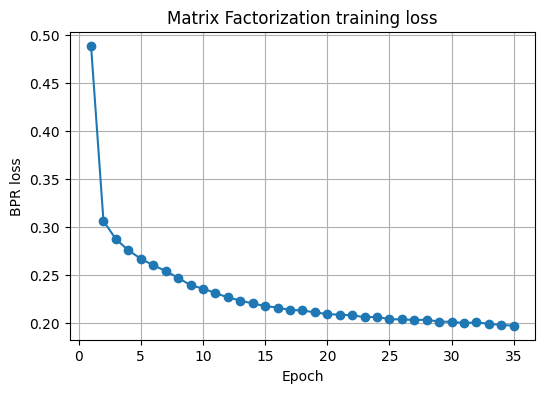

In [ ]:
# ============================================================
# Cell 9 (UPDATED) — Train Matrix Factorization with early stopping + LR scheduling + L2
# ============================================================
mf_model = MatrixFactorization(NUM_USERS, NUM_ITEMS, EMBEDDING_DIM).to(DEVICE)
mf_optimizer = torch.optim.Adam(mf_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
mf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    mf_optimizer, mode="max", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE, min_lr=LR_MIN
)

mf_train_losses = []
mf_val_ndcg20_history = []
best_val_ndcg20 = -1.0
best_mf_state = None
best_mf_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, MF_MAX_EPOCHS + 1):
    mf_model.train()
    epoch_loss = 0.0
    num_batches = 0

    loader = get_bpr_dataloader(batch_size=BATCH_SIZE, shuffle=True)
    for user_batch, pos_batch, neg_batch in loader:
        user_batch = user_batch.to(DEVICE).long()
        pos_batch = pos_batch.to(DEVICE).long()
        neg_batch = neg_batch.to(DEVICE).long()

        pos_scores, neg_scores = mf_model(user_batch, pos_batch, neg_batch)
        loss = bpr_loss(pos_scores, neg_scores)

        mf_optimizer.zero_grad()
        loss.backward()
        mf_optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    mf_train_losses.append(avg_loss)

    mf_model.eval()
    with torch.no_grad():
        user_emb, item_emb = mf_model.get_all_embeddings()
        score_fn = make_embedding_score_fn(user_emb, item_emb)
        val_metrics = evaluate_topk(score_fn, user_val_item, user_train_items_set, NUM_ITEMS)

    mf_val_ndcg20_history.append(val_metrics["NDCG@20"])
    mf_scheduler.step(val_metrics["NDCG@20"])
    current_lr = mf_optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch}/{MF_MAX_EPOCHS} - loss: {avg_loss:.4f} - "
          f"val Recall@20: {val_metrics['Recall@20']:.4f} - val NDCG@20: {val_metrics['NDCG@20']:.4f} - "
          f"lr: {current_lr:.6f}")

    if val_metrics["NDCG@20"] > best_val_ndcg20:
        best_val_ndcg20 = val_metrics["NDCG@20"]
        best_mf_epoch = epoch
        best_mf_state = {k: v.clone() for k, v in mf_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch} "
              f"(no improvement for {EARLY_STOP_PATIENCE} consecutive epochs).")
        break

if best_mf_state is not None:
    mf_model.load_state_dict(best_mf_state)

print(f"Best MF validation NDCG@20: {best_val_ndcg20:.4f} at epoch {best_mf_epoch}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(mf_train_losses) + 1), mf_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("Matrix Factorization training loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Final Stage 1 cell (UPDATED) — Evaluate MF and update results
# ============================================================
mf_model.eval()
with torch.no_grad():
    user_emb, item_emb = mf_model.get_all_embeddings()
    mf_score_fn = make_embedding_score_fn(user_emb, item_emb)
    mf_test_metrics = evaluate_topk(mf_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS)

results["Matrix Factorization"] = mf_test_metrics

results_df = pd.DataFrame(results).T
results_df = results_df[["Recall@10", "Recall@20", "NDCG@10", "NDCG@20"]]

print("Popularity:")
print(f"  Recall@10 = {results['Popularity']['Recall@10']:.4f}")
print(f"  Recall@20 = {results['Popularity']['Recall@20']:.4f}")
print(f"  NDCG@10   = {results['Popularity']['NDCG@10']:.4f}")
print(f"  NDCG@20   = {results['Popularity']['NDCG@20']:.4f}")
print()
print("Matrix Factorization:")
print(f"  Recall@10 = {results['Matrix Factorization']['Recall@10']:.4f}")
print(f"  Recall@20 = {results['Matrix Factorization']['Recall@20']:.4f}")
print(f"  NDCG@10   = {results['Matrix Factorization']['NDCG@10']:.4f}")
print(f"  NDCG@20   = {results['Matrix Factorization']['NDCG@20']:.4f}")
print()
print(results_df)

Popularity:
  Recall@10 = 0.0414
  Recall@20 = 0.0729
  NDCG@10   = 0.0194
  NDCG@20   = 0.0272

Matrix Factorization:
  Recall@10 = 0.0613
  Recall@20 = 0.1042
  NDCG@10   = 0.0308
  NDCG@20   = 0.0415

                      Recall@10  Recall@20   NDCG@10   NDCG@20
Popularity             0.041432   0.072920  0.019364  0.027217
Matrix Factorization   0.061319   0.104243  0.030762  0.041525


In [ ]:
# ============================================================
# Cell 10 — Build sparse training graph (shared by NGCF & LightGCN)
# ============================================================
import scipy.sparse as sp

NGCF_LGCN_EMBEDDING_DIM = 64
NGCF_LGCN_N_LAYERS = 3
NGCF_LGCN_LEARNING_RATE = 1e-3
GRAPH_NUM_EPOCHS = NUM_EPOCHS

def build_norm_adj(train_user_array, train_item_array, num_users, num_items):
    """
    Build the symmetrically normalized bipartite user-item adjacency matrix
    D^{-1/2} A D^{-1/2} using TRAINING interactions only, as a torch sparse
    tensor. No dense matrix is ever materialized.
    """
    num_nodes = num_users + num_items

    user_nodes = train_user_array
    item_nodes = train_item_array + num_users

    rows = np.concatenate([user_nodes, item_nodes])
    cols = np.concatenate([item_nodes, user_nodes])
    data = np.ones(len(rows), dtype=np.float32)

    adj = sp.coo_matrix((data, (rows, cols)), shape=(num_nodes, num_nodes))

    degree = np.array(adj.sum(axis=1)).flatten()
    degree[degree == 0] = 1.0
    d_inv_sqrt = np.power(degree, -0.5)
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)

    norm_adj = d_mat_inv_sqrt.dot(adj).dot(d_mat_inv_sqrt).tocoo()

    indices = torch.tensor(np.vstack([norm_adj.row, norm_adj.col]), dtype=torch.long)
    values = torch.tensor(norm_adj.data, dtype=torch.float32)
    shape = torch.Size(norm_adj.shape)

    sparse_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce()
    return sparse_tensor


norm_adj_sparse = build_norm_adj(train_user_array, train_item_array, NUM_USERS, NUM_ITEMS).to(DEVICE)
print("Sparse normalized adjacency shape:", norm_adj_sparse.shape)
print("Number of non-zero entries:", norm_adj_sparse._nnz())

Sparse normalized adjacency shape: torch.Size([9567, 9567])
Number of non-zero entries: 1126408


/tmp/ipykernel_2105/3468795424.py:39: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  sparse_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce()


In [ ]:
# ============================================================
# Cell 11 — NGCF model
# ============================================================
class NGCF(nn.Module):
    def __init__(self, num_users, num_items, norm_adj, embedding_dim=NGCF_LGCN_EMBEDDING_DIM,
                 n_layers=NGCF_LGCN_N_LAYERS, dropout=0.1):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.norm_adj = norm_adj
        self.n_layers = n_layers
        self.dropout = dropout

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

        self.W1 = nn.ModuleList()
        self.W2 = nn.ModuleList()
        for _ in range(n_layers):
            self.W1.append(nn.Linear(embedding_dim, embedding_dim))
            self.W2.append(nn.Linear(embedding_dim, embedding_dim))

        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)

    def propagate(self):
        ego_embeddings = torch.cat(
            [self.user_embedding.weight, self.item_embedding.weight], dim=0
        )
        all_layer_embeddings = [ego_embeddings]

        for layer in range(self.n_layers):
            side_embeddings = torch.sparse.mm(self.norm_adj, ego_embeddings)

            sum_embeddings = self.W1[layer](side_embeddings)

            bi_embeddings = torch.mul(ego_embeddings, side_embeddings)
            bi_embeddings = self.W2[layer](bi_embeddings)

            ego_embeddings = self.leaky_relu(sum_embeddings + bi_embeddings)
            ego_embeddings = F.dropout(ego_embeddings, p=self.dropout, training=self.training)
            ego_embeddings = F.normalize(ego_embeddings, p=2, dim=1)

            all_layer_embeddings.append(ego_embeddings)

        final_embeddings = torch.cat(all_layer_embeddings, dim=1)
        user_final, item_final = torch.split(
            final_embeddings, [self.num_users, self.num_items], dim=0
        )
        return user_final, item_final

    def forward(self, user_idx, pos_item_idx, neg_item_idx):
        user_final, item_final = self.propagate()
        u = user_final[user_idx]
        pos = item_final[pos_item_idx]
        neg = item_final[neg_item_idx]
        pos_scores = (u * pos).sum(dim=1)
        neg_scores = (u * neg).sum(dim=1)
        return pos_scores, neg_scores

    def get_all_embeddings(self):
        with torch.no_grad():
            was_training = self.training
            self.eval()
            user_final, item_final = self.propagate()
            self.train(was_training)
        return user_final, item_final

In [ ]:
# ============================================================
# Cell 12 — LightGCN model
# ============================================================
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, norm_adj, embedding_dim=NGCF_LGCN_EMBEDDING_DIM,
                 n_layers=NGCF_LGCN_N_LAYERS):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.norm_adj = norm_adj
        self.n_layers = n_layers

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

    def propagate(self):
        ego_embeddings = torch.cat(
            [self.user_embedding.weight, self.item_embedding.weight], dim=0
        )
        all_layer_embeddings = [ego_embeddings]

        for layer in range(self.n_layers):
            ego_embeddings = torch.sparse.mm(self.norm_adj, ego_embeddings)
            all_layer_embeddings.append(ego_embeddings)

        stacked_embeddings = torch.stack(all_layer_embeddings, dim=1)
        final_embeddings = torch.mean(stacked_embeddings, dim=1)

        user_final, item_final = torch.split(
            final_embeddings, [self.num_users, self.num_items], dim=0
        )
        return user_final, item_final

    def forward(self, user_idx, pos_item_idx, neg_item_idx):
        user_final, item_final = self.propagate()
        u = user_final[user_idx]
        pos = item_final[pos_item_idx]
        neg = item_final[neg_item_idx]
        pos_scores = (u * pos).sum(dim=1)
        neg_scores = (u * neg).sum(dim=1)
        return pos_scores, neg_scores

    def get_all_embeddings(self):
        with torch.no_grad():
            was_training = self.training
            self.eval()
            user_final, item_final = self.propagate()
            self.train(was_training)
        return user_final, item_final

In [ ]:
# ============================================================
# Cell 13 (UPDATED) — Generic graph-model training loop with early stopping + LR scheduling + L2
# ============================================================
def train_graph_model(model, model_name, max_epochs, learning_rate=NGCF_LGCN_LEARNING_RATE,
                       batch_size=BATCH_SIZE, patience=EARLY_STOP_PATIENCE,
                       lr_factor=LR_SCHEDULER_FACTOR, lr_patience=LR_SCHEDULER_PATIENCE, lr_min=LR_MIN,
                       weight_decay=L2_REG):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=lr_factor, patience=lr_patience, min_lr=lr_min
    )

    train_losses = []
    val_ndcg20_history = []
    best_val_ndcg20 = -1.0
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        loader = get_bpr_dataloader(batch_size=batch_size, shuffle=True)
        for user_batch, pos_batch, neg_batch in loader:
            user_batch = user_batch.to(DEVICE).long()
            pos_batch = pos_batch.to(DEVICE).long()
            neg_batch = neg_batch.to(DEVICE).long()

            pos_scores, neg_scores = model(user_batch, pos_batch, neg_batch)
            loss = bpr_loss(pos_scores, neg_scores)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        model.eval()
        with torch.no_grad():
            user_emb, item_emb = model.get_all_embeddings()
            score_fn = make_embedding_score_fn(user_emb, item_emb)
            val_metrics = evaluate_topk(score_fn, user_val_item, user_train_items_set, NUM_ITEMS)

        val_ndcg20_history.append(val_metrics["NDCG@20"])
        scheduler.step(val_metrics["NDCG@20"])
        current_lr = optimizer.param_groups[0]["lr"]

        print(f"[{model_name}] Epoch {epoch}/{max_epochs} - loss: {avg_loss:.4f} - "
              f"val Recall@20: {val_metrics['Recall@20']:.4f} - val NDCG@20: {val_metrics['NDCG@20']:.4f} - "
              f"lr: {current_lr:.6f}")

        if val_metrics["NDCG@20"] > best_val_ndcg20:
            best_val_ndcg20 = val_metrics["NDCG@20"]
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"[{model_name}] Early stopping triggered at epoch {epoch} "
                  f"(no improvement for {patience} consecutive epochs).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"[{model_name}] Best validation NDCG@20: {best_val_ndcg20:.4f} at epoch {best_epoch}")

    return model, train_losses, val_ndcg20_history

[NGCF] Epoch 1/50 - loss: 0.3530 - val Recall@20: 0.0703 - val NDCG@20: 0.0272 - lr: 0.001000
[NGCF] Epoch 2/50 - loss: 0.2542 - val Recall@20: 0.0844 - val NDCG@20: 0.0330 - lr: 0.001000
[NGCF] Epoch 3/50 - loss: 0.2349 - val Recall@20: 0.0958 - val NDCG@20: 0.0378 - lr: 0.001000
[NGCF] Epoch 4/50 - loss: 0.2237 - val Recall@20: 0.1021 - val NDCG@20: 0.0403 - lr: 0.001000
[NGCF] Epoch 5/50 - loss: 0.2194 - val Recall@20: 0.1081 - val NDCG@20: 0.0418 - lr: 0.001000
[NGCF] Epoch 6/50 - loss: 0.2140 - val Recall@20: 0.1142 - val NDCG@20: 0.0451 - lr: 0.001000
[NGCF] Epoch 7/50 - loss: 0.2096 - val Recall@20: 0.1163 - val NDCG@20: 0.0470 - lr: 0.001000
[NGCF] Epoch 8/50 - loss: 0.2046 - val Recall@20: 0.1167 - val NDCG@20: 0.0462 - lr: 0.001000
[NGCF] Epoch 9/50 - loss: 0.2021 - val Recall@20: 0.1182 - val NDCG@20: 0.0463 - lr: 0.001000
[NGCF] Epoch 10/50 - loss: 0.2005 - val Recall@20: 0.1250 - val NDCG@20: 0.0492 - lr: 0.001000
[NGCF] Epoch 11/50 - loss: 0.1976 - val Recall@20: 0.1221 -

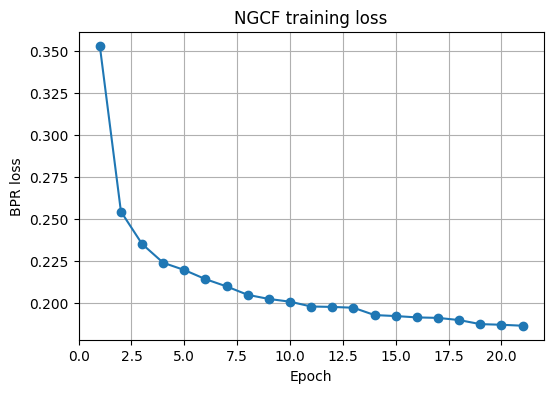

In [ ]:
# ============================================================
# Cell 14 (UPDATED) — Train NGCF
# ============================================================
ngcf_model = NGCF(
    NUM_USERS, NUM_ITEMS, norm_adj_sparse,
    embedding_dim=NGCF_LGCN_EMBEDDING_DIM, n_layers=NGCF_LGCN_N_LAYERS
).to(DEVICE)

ngcf_model, ngcf_train_losses, ngcf_val_ndcg20_history = train_graph_model(
    ngcf_model, "NGCF", max_epochs=NGCF_MAX_EPOCHS, learning_rate=NGCF_LGCN_LEARNING_RATE
)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(ngcf_train_losses) + 1), ngcf_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("NGCF training loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Cell 15 (UPDATED) — Evaluate NGCF on test set
# ============================================================
ngcf_model.eval()
with torch.no_grad():
    ngcf_user_emb, ngcf_item_emb = ngcf_model.get_all_embeddings()
    ngcf_score_fn = make_embedding_score_fn(ngcf_user_emb, ngcf_item_emb)
    ngcf_test_metrics = evaluate_topk(ngcf_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS)

results["NGCF"] = ngcf_test_metrics

print("NGCF (test):")
for k, v in ngcf_test_metrics.items():
    print(f"  {k} = {v:.4f}")

NGCF (test):
  Recall@10 = 0.0679
  NDCG@10 = 0.0324
  Recall@20 = 0.1115
  NDCG@20 = 0.0434


[LightGCN] Epoch 1/70 - loss: 0.3850 - val Recall@20: 0.0817 - val NDCG@20: 0.0310 - lr: 0.001000
[LightGCN] Epoch 2/70 - loss: 0.3109 - val Recall@20: 0.0812 - val NDCG@20: 0.0307 - lr: 0.001000
[LightGCN] Epoch 3/70 - loss: 0.3050 - val Recall@20: 0.0799 - val NDCG@20: 0.0303 - lr: 0.001000
[LightGCN] Epoch 4/70 - loss: 0.3014 - val Recall@20: 0.0805 - val NDCG@20: 0.0308 - lr: 0.001000
[LightGCN] Epoch 5/70 - loss: 0.2972 - val Recall@20: 0.0824 - val NDCG@20: 0.0313 - lr: 0.001000
[LightGCN] Epoch 6/70 - loss: 0.2935 - val Recall@20: 0.0820 - val NDCG@20: 0.0313 - lr: 0.001000
[LightGCN] Epoch 7/70 - loss: 0.2888 - val Recall@20: 0.0832 - val NDCG@20: 0.0316 - lr: 0.001000
[LightGCN] Epoch 8/70 - loss: 0.2751 - val Recall@20: 0.0852 - val NDCG@20: 0.0327 - lr: 0.001000
[LightGCN] Epoch 9/70 - loss: 0.2610 - val Recall@20: 0.0862 - val NDCG@20: 0.0328 - lr: 0.001000
[LightGCN] Epoch 10/70 - loss: 0.2522 - val Recall@20: 0.0853 - val NDCG@20: 0.0323 - lr: 0.001000
[LightGCN] Epoch 11

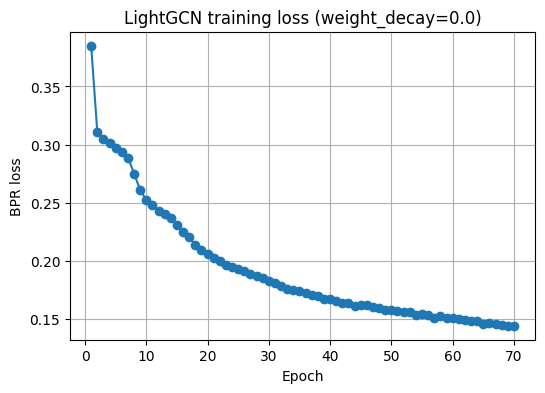

In [ ]:
# ============================================================
# Cell 16 (RETRY 2) — Retrain LightGCN with weight_decay disabled
# ============================================================
# Diagnostic: the plateau reproduced across two different seeds, ruling out
# unlucky init. Most likely cause is L2_REG interacting badly with
# LightGCN's small-magnitude, non-transformed embedding table (unlike NGCF,
# which has learnable per-layer weights to absorb the regularization).
# Testing with weight_decay=0.0 for LightGCN specifically; every other
# model keeps L2_REG unchanged.

lightgcn_model = LightGCN(
    NUM_USERS, NUM_ITEMS, norm_adj_sparse,
    embedding_dim=NGCF_LGCN_EMBEDDING_DIM, n_layers=NGCF_LGCN_N_LAYERS
).to(DEVICE)

lightgcn_model, lightgcn_train_losses, lightgcn_val_ndcg20_history = train_graph_model(
    lightgcn_model, "LightGCN", max_epochs=LIGHTGCN_MAX_EPOCHS,
    learning_rate=NGCF_LGCN_LEARNING_RATE, weight_decay=0.0
)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(lightgcn_train_losses) + 1), lightgcn_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("LightGCN training loss (weight_decay=0.0)")
plt.grid(True)
plt.show()

In [ ]:
with torch.no_grad():
    u_emb, i_emb = lightgcn_model.get_all_embeddings()
    print("user emb norm (mean):", u_emb.norm(dim=1).mean().item())
    print("item emb norm (mean):", i_emb.norm(dim=1).mean().item())
print("LightGCN val NDCG@20 per epoch:", lightgcn_val_ndcg20_history)
print("LightGCN train loss per epoch:", lightgcn_train_losses)

user emb norm (mean): 2.212961435317993
item emb norm (mean): 2.670332670211792
LightGCN val NDCG@20 per epoch: [np.float64(0.03097779447344072), np.float64(0.030672375869044758), np.float64(0.03033930774767453), np.float64(0.030830201884363525), np.float64(0.03127257240413925), np.float64(0.03128452235246795), np.float64(0.03162324681115587), np.float64(0.03274399873885893), np.float64(0.032807437028715136), np.float64(0.03226192070437211), np.float64(0.032300189649471116), np.float64(0.03266701733701513), np.float64(0.03289631942964657), np.float64(0.033740590464626484), np.float64(0.035357637989390386), np.float64(0.037178399453716135), np.float64(0.03841726744334977), np.float64(0.03899631229065613), np.float64(0.039770734264376065), np.float64(0.04031763660272727), np.float64(0.04094729655608074), np.float64(0.04153243855389356), np.float64(0.04244804012071678), np.float64(0.042494452008163895), np.float64(0.04208223150147835), np.float64(0.04280426224798552), np.float64(0.0433659

In [ ]:
# ============================================================
# Cell 17 (UPDATED) — Evaluate LightGCN on test set
# ============================================================
lightgcn_model.eval()
with torch.no_grad():
    lightgcn_user_emb, lightgcn_item_emb = lightgcn_model.get_all_embeddings()
    lightgcn_score_fn = make_embedding_score_fn(lightgcn_user_emb, lightgcn_item_emb)
    lightgcn_test_metrics = evaluate_topk(lightgcn_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS)

results["LightGCN"] = lightgcn_test_metrics

print("LightGCN (test):")
for k, v in lightgcn_test_metrics.items():
    print(f"  {k} = {v:.4f}")

LightGCN (test):
  Recall@10 = 0.0686
  NDCG@10 = 0.0344
  Recall@20 = 0.1195
  NDCG@20 = 0.0471


In [ ]:
# ============================================================
# Cell 18 — Updated results summary
# ============================================================
results_df = pd.DataFrame(results).T
results_df = results_df[["Recall@10", "Recall@20", "NDCG@10", "NDCG@20"]]
results_df = results_df.loc[
    [m for m in ["Popularity", "Matrix Factorization", "NGCF", "LightGCN"] if m in results_df.index]
]

print(results_df)

                      Recall@10  Recall@20   NDCG@10   NDCG@20
Popularity             0.041432   0.072920  0.019364  0.027217
Matrix Factorization   0.061319   0.104243  0.030762  0.041525
NGCF                   0.067948   0.111535  0.032399  0.043365
LightGCN               0.068611   0.119490  0.034369  0.047080


In [ ]:
# ============================================================
# Cell 19 — Sequential training examples (Transformer, train-only)
# ============================================================
MAX_SEQ_LEN = 50
PAD_ITEM_IDX = NUM_ITEMS  # reserved padding index, separate from real item indices [0, NUM_ITEMS-1]

TFM_EMBEDDING_DIM = 64
TFM_NUM_HEADS = 4
TFM_NUM_LAYERS = 2
TFM_DROPOUT = 0.1
TFM_LEARNING_RATE = 1e-3
TFM_BATCH_SIZE = 512
TFM_NUM_EPOCHS = 20

seq_examples = []  # list of (user_idx, input_items(list[int]), target_item(int))

for user_idx, items in user_train_items.items():
    if len(items) < 2:
        continue
    for t in range(1, len(items)):
        start = max(0, t - MAX_SEQ_LEN)
        input_items = items[start:t]
        target_item = items[t]
        seq_examples.append((user_idx, input_items, target_item))

print(f"Number of sequential training examples: {len(seq_examples)}")
print("Example:", seq_examples[0])

Number of sequential training examples: 557170
Example: (0, [2837], 1113)


In [ ]:
# ============================================================
# Cell 20 (UPDATED) — Vectorized sequential negative sampling
# ============================================================
def pad_sequences(list_of_item_lists, max_len=MAX_SEQ_LEN, pad_idx=PAD_ITEM_IDX):
    """
    Right-pads a batch of variable-length item-index lists to max_len.
    Returns (padded_tensor [B, max_len], lengths_tensor [B]).
    Kept unchanged — still used directly by make_transformer_score_fn
    and make_hybrid_score_fn at evaluation time.
    """
    batch_size = len(list_of_item_lists)
    padded = np.full((batch_size, max_len), pad_idx, dtype=np.int64)
    lengths = np.zeros(batch_size, dtype=np.int64)

    for i, seq in enumerate(list_of_item_lists):
        seq = seq[-max_len:]
        L = len(seq)
        if L == 0:
            L = 1
            seq = [pad_idx]
        padded[i, :L] = seq
        lengths[i] = L

    return torch.tensor(padded, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


# Sequences/lengths never change across epochs — only negatives do —
# so pad and cache them ONCE here rather than re-padding every batch.
seq_user_array = np.array([ex[0] for ex in seq_examples], dtype=np.int64)
seq_target_array = np.array([ex[2] for ex in seq_examples], dtype=np.int64)

_seq_input_lists = [ex[1] for ex in seq_examples]
_padded, _lengths = pad_sequences(_seq_input_lists, max_len=MAX_SEQ_LEN, pad_idx=PAD_ITEM_IDX)
seq_input_padded = _padded.numpy()
seq_lengths_array = _lengths.numpy()


def get_seq_bpr_dataloader(batch_size=TFM_BATCH_SIZE, shuffle=True):
    """
    Same signature/behavior as before (yields user, seq, lengths, target,
    neg batches), reusing the cached padded sequences above. Negatives
    are resampled each call using the same vectorized sparse-matrix
    check as get_bpr_dataloader. Drop-in replacement — SeqBPRTrainDataset
    and seq_bpr_collate_fn are no longer needed and are removed.
    """
    neg_array = sample_negatives_vectorized(seq_user_array, train_pos_csr, NUM_ITEMS)

    user_tensor = torch.from_numpy(seq_user_array).long()
    seq_tensor = torch.from_numpy(seq_input_padded).long()
    len_tensor = torch.from_numpy(seq_lengths_array).long()
    target_tensor = torch.from_numpy(seq_target_array).long()
    neg_tensor = torch.from_numpy(neg_array).long()

    dataset = torch.utils.data.TensorDataset(user_tensor, seq_tensor, len_tensor, target_tensor, neg_tensor)
    return torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False, pin_memory=True
    )


sample_seq_loader = get_seq_bpr_dataloader(batch_size=4)
sample_seq_batch = next(iter(sample_seq_loader))
print("Sample sequential batch shapes:", [x.shape for x in sample_seq_batch])

Sample sequential batch shapes: [torch.Size([4]), torch.Size([4, 50]), torch.Size([4]), torch.Size([4]), torch.Size([4])]


In [ ]:
# ============================================================
# Cell 21 — Transformer sequential recommender
# ============================================================
class TransformerRecommender(nn.Module):
    def __init__(self, num_items, embedding_dim=TFM_EMBEDDING_DIM, num_heads=TFM_NUM_HEADS,
                 num_layers=TFM_NUM_LAYERS, dropout=TFM_DROPOUT, max_seq_len=MAX_SEQ_LEN,
                 pad_idx=PAD_ITEM_IDX):
        super().__init__()
        self.num_items = num_items
        self.max_seq_len = max_seq_len
        self.pad_idx = pad_idx

        self.item_embedding = nn.Embedding(num_items + 1, embedding_dim, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_seq_len, embedding_dim)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        nn.init.normal_(self.position_embedding.weight, std=0.01)
        with torch.no_grad():
            self.item_embedding.weight[pad_idx].fill_(0.0)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embedding_dim)

    def encode(self, input_seq, lengths):
        """
        input_seq: [B, L] item indices (right-padded with pad_idx)
        lengths:   [B]    actual (unpadded) sequence lengths
        Returns representation at the last real position: [B, D]
        """
        batch_size, seq_len = input_seq.shape
        device = input_seq.device

        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, -1)
        x = self.item_embedding(input_seq) + self.position_embedding(positions)
        x = self.dropout(x)

        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)
        padding_mask = (input_seq == self.pad_idx)

        out = self.transformer_encoder(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        out = self.layer_norm(out)

        gather_idx = (lengths - 1).clamp(min=0)
        batch_arange = torch.arange(batch_size, device=device)
        last_hidden = out[batch_arange, gather_idx, :]
        return last_hidden

    def forward(self, input_seq, lengths, pos_item_idx, neg_item_idx):
        repr_vec = self.encode(input_seq, lengths)
        pos_emb = self.item_embedding(pos_item_idx)
        neg_emb = self.item_embedding(neg_item_idx)
        pos_scores = (repr_vec * pos_emb).sum(dim=1)
        neg_scores = (repr_vec * neg_emb).sum(dim=1)
        return pos_scores, neg_scores

    def score_all_items(self, input_seq, lengths):
        repr_vec = self.encode(input_seq, lengths)
        item_matrix = self.item_embedding.weight[:self.num_items]  # exclude pad row
        return repr_vec @ item_matrix.T

In [ ]:
# ============================================================
# Cell 22 — Transformer-compatible score_fn for evaluate_topk
# ============================================================
def make_transformer_score_fn(model, user_train_items, max_len=MAX_SEQ_LEN, pad_idx=PAD_ITEM_IDX,
                               device=DEVICE):
    """
    Builds a score_fn(user_idx_tensor) -> [B, NUM_ITEMS] compatible with the
    existing evaluate_topk(). For each user, the input sequence is built ONLY
    from user_train_items (last max_len items), never validation/test items.
    """
    def score_fn(user_idx_tensor):
        user_list = user_idx_tensor.cpu().numpy().tolist()
        input_lists = [user_train_items.get(u, []) for u in user_list]
        padded_seqs, lengths = pad_sequences(input_lists, max_len=max_len, pad_idx=pad_idx)
        padded_seqs = padded_seqs.to(device)
        lengths = lengths.to(device)

        model.eval()
        with torch.no_grad():
            scores = model.score_all_items(padded_seqs, lengths)
        return scores

    return score_fn

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


[Transformer] Epoch 1/70 - loss: 0.2572 - val Recall@20: 0.1495 - val NDCG@20: 0.0596 - lr: 0.001000
[Transformer] Epoch 2/70 - loss: 0.1567 - val Recall@20: 0.1917 - val NDCG@20: 0.0775 - lr: 0.001000
[Transformer] Epoch 3/70 - loss: 0.1371 - val Recall@20: 0.2163 - val NDCG@20: 0.0885 - lr: 0.001000
[Transformer] Epoch 4/70 - loss: 0.1260 - val Recall@20: 0.2290 - val NDCG@20: 0.0947 - lr: 0.001000
[Transformer] Epoch 5/70 - loss: 0.1177 - val Recall@20: 0.2458 - val NDCG@20: 0.1015 - lr: 0.001000
[Transformer] Epoch 6/70 - loss: 0.1130 - val Recall@20: 0.2521 - val NDCG@20: 0.1050 - lr: 0.001000
[Transformer] Epoch 7/70 - loss: 0.1091 - val Recall@20: 0.2574 - val NDCG@20: 0.1069 - lr: 0.001000
[Transformer] Epoch 8/70 - loss: 0.1058 - val Recall@20: 0.2658 - val NDCG@20: 0.1107 - lr: 0.001000
[Transformer] Epoch 9/70 - loss: 0.1021 - val Recall@20: 0.2708 - val NDCG@20: 0.1158 - lr: 0.001000
[Transformer] Epoch 10/70 - loss: 0.1004 - val Recall@20: 0.2736 - val NDCG@20: 0.1163 - lr

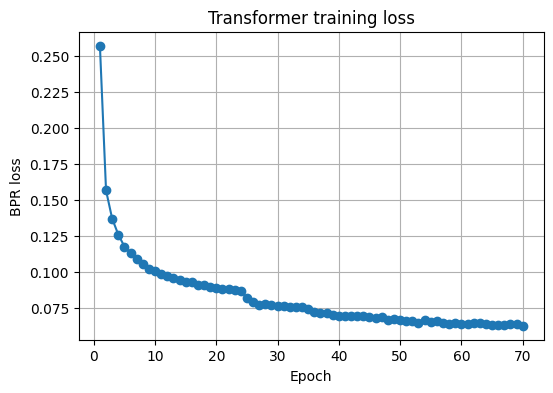

In [ ]:
# ============================================================
# Cell 23 (UPDATED) — Train Transformer with early stopping + LR scheduling + L2
# ============================================================
transformer_model = TransformerRecommender(
    num_items=NUM_ITEMS,
    embedding_dim=TFM_EMBEDDING_DIM,
    num_heads=TFM_NUM_HEADS,
    num_layers=TFM_NUM_LAYERS,
    dropout=TFM_DROPOUT,
    max_seq_len=MAX_SEQ_LEN,
    pad_idx=PAD_ITEM_IDX,
).to(DEVICE)

tfm_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=TFM_LEARNING_RATE, weight_decay=L2_REG)
tfm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tfm_optimizer, mode="max", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE, min_lr=LR_MIN
)

transformer_train_losses = []
transformer_val_ndcg20_history = []
best_transformer_val_ndcg20 = -1.0
best_transformer_state = None
best_transformer_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, TFM_MAX_EPOCHS + 1):
    transformer_model.train()
    epoch_loss = 0.0
    num_batches = 0

    loader = get_seq_bpr_dataloader(batch_size=TFM_BATCH_SIZE, shuffle=True)
    for user_batch, seq_batch, len_batch, target_batch, neg_batch in loader:
        seq_batch = seq_batch.to(DEVICE)
        len_batch = len_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)
        neg_batch = neg_batch.to(DEVICE)

        pos_scores, neg_scores = transformer_model(seq_batch, len_batch, target_batch, neg_batch)
        loss = bpr_loss(pos_scores, neg_scores)

        tfm_optimizer.zero_grad()
        loss.backward()
        tfm_optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    transformer_train_losses.append(avg_loss)

    transformer_score_fn = make_transformer_score_fn(transformer_model, user_train_items)
    val_metrics = evaluate_topk(transformer_score_fn, user_val_item, user_train_items_set, NUM_ITEMS)
    transformer_val_ndcg20_history.append(val_metrics["NDCG@20"])

    tfm_scheduler.step(val_metrics["NDCG@20"])
    current_lr = tfm_optimizer.param_groups[0]["lr"]

    print(f"[Transformer] Epoch {epoch}/{TFM_MAX_EPOCHS} - loss: {avg_loss:.4f} - "
          f"val Recall@20: {val_metrics['Recall@20']:.4f} - val NDCG@20: {val_metrics['NDCG@20']:.4f} - "
          f"lr: {current_lr:.6f}")

    if val_metrics["NDCG@20"] > best_transformer_val_ndcg20:
        best_transformer_val_ndcg20 = val_metrics["NDCG@20"]
        best_transformer_epoch = epoch
        best_transformer_state = {k: v.clone() for k, v in transformer_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"[Transformer] Early stopping triggered at epoch {epoch} "
              f"(no improvement for {EARLY_STOP_PATIENCE} consecutive epochs).")
        break

if best_transformer_state is not None:
    transformer_model.load_state_dict(best_transformer_state)

print(f"[Transformer] Best validation NDCG@20: {best_transformer_val_ndcg20:.4f} at epoch {best_transformer_epoch}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(transformer_train_losses) + 1), transformer_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("Transformer training loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Cell 24 (UPDATED) — Evaluate Transformer on test set
# ============================================================
transformer_model.eval()
transformer_test_score_fn = make_transformer_score_fn(transformer_model, user_train_items)
transformer_test_metrics = evaluate_topk(
    transformer_test_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS
)

results["Transformer"] = transformer_test_metrics

print("Transformer (test):")
for k, v in transformer_test_metrics.items():
    print(f"  {k} = {v:.4f}")

Transformer (test):
  Recall@10 = 0.1821
  NDCG@10 = 0.0964
  Recall@20 = 0.2797
  NDCG@20 = 0.1209


In [ ]:
# ============================================================
# Cell 25 — Updated results summary
# ============================================================
results_df = pd.DataFrame(results).T
results_df = results_df[["Recall@10", "Recall@20", "NDCG@10", "NDCG@20"]]
results_df = results_df.loc[
    [m for m in ["Popularity", "Matrix Factorization", "NGCF", "LightGCN", "Transformer"]
     if m in results_df.index]
]

print(results_df)

                      Recall@10  Recall@20   NDCG@10   NDCG@20
Popularity             0.041432   0.072920  0.019364  0.027217
Matrix Factorization   0.061319   0.104243  0.030762  0.041525
NGCF                   0.067948   0.111535  0.032399  0.043365
LightGCN               0.068611   0.119490  0.034369  0.047080
Transformer            0.182135   0.279748  0.096393  0.120904


In [ ]:
# ============================================================
# Cell 26 — LightGCN + Transformer hybrid model
# ============================================================
import time

HYBRID_LEARNING_RATE = 1e-3
HYBRID_BATCH_SIZE = 512
HYBRID_NUM_EPOCHS = 20
HYBRID_DROPOUT = 0.1


class LightGCNTransformerHybrid(nn.Module):
    """
    Combines an (already-initialized) LightGCN module and an
    (already-initialized) TransformerRecommender module via a small
    fusion MLP over the user representations. Item scoring always
    uses LightGCN item embeddings.
    """
    def __init__(self, lightgcn_module, transformer_module, embedding_dim=64, dropout=HYBRID_DROPOUT):
        super().__init__()
        self.lightgcn = lightgcn_module
        self.transformer = transformer_module

        self.fusion = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, embedding_dim),
        )

    def compute_graph_embeddings(self):
        return self.lightgcn.propagate()

    def fuse(self, graph_user, seq_user):
        return self.fusion(torch.cat([graph_user, seq_user], dim=1))

    def forward(self, user_idx, input_seq, lengths, pos_item_idx, neg_item_idx):
        graph_user_all, graph_item_all = self.compute_graph_embeddings()

        graph_user = graph_user_all[user_idx]
        seq_user = self.transformer.encode(input_seq, lengths)
        hybrid_user = self.fuse(graph_user, seq_user)

        pos_emb = graph_item_all[pos_item_idx]
        neg_emb = graph_item_all[neg_item_idx]

        pos_scores = (hybrid_user * pos_emb).sum(dim=1)
        neg_scores = (hybrid_user * neg_emb).sum(dim=1)
        return pos_scores, neg_scores

In [ ]:
# ============================================================
# Cell 27 — Build hybrid model and initialize from best checkpoints
# ============================================================
hybrid_lightgcn = LightGCN(
    NUM_USERS, NUM_ITEMS, norm_adj_sparse,
    embedding_dim=NGCF_LGCN_EMBEDDING_DIM, n_layers=NGCF_LGCN_N_LAYERS
).to(DEVICE)

hybrid_transformer = TransformerRecommender(
    num_items=NUM_ITEMS,
    embedding_dim=TFM_EMBEDDING_DIM,
    num_heads=TFM_NUM_HEADS,
    num_layers=TFM_NUM_LAYERS,
    dropout=TFM_DROPOUT,
    max_seq_len=MAX_SEQ_LEN,
    pad_idx=PAD_ITEM_IDX,
).to(DEVICE)

if "lightgcn_model" in globals():
    hybrid_lightgcn.load_state_dict(lightgcn_model.state_dict())
    print("Initialized LightGCN component from best Stage 2 LightGCN checkpoint.")
elif "best_lightgcn_state" in globals():
    hybrid_lightgcn.load_state_dict(best_lightgcn_state)
    print("Initialized LightGCN component from best_lightgcn_state.")
else:
    print("WARNING: no existing LightGCN checkpoint found, using random init.")

if "best_transformer_state" in globals() and best_transformer_state is not None:
    hybrid_transformer.load_state_dict(best_transformer_state)
    print("Initialized Transformer component from best_transformer_state.")
elif "transformer_model" in globals():
    hybrid_transformer.load_state_dict(transformer_model.state_dict())
    print("Initialized Transformer component from transformer_model.")
else:
    print("WARNING: no existing Transformer checkpoint found, using random init.")

hybrid_model = LightGCNTransformerHybrid(
    hybrid_lightgcn, hybrid_transformer,
    embedding_dim=NGCF_LGCN_EMBEDDING_DIM, dropout=HYBRID_DROPOUT
).to(DEVICE)

Initialized LightGCN component from best Stage 2 LightGCN checkpoint.
Initialized Transformer component from best_transformer_state.


In [ ]:
# ============================================================
# Cell 28 — Hybrid-specific score function for evaluate_topk
# ============================================================
def make_hybrid_score_fn(model, user_train_items, max_len=MAX_SEQ_LEN, pad_idx=PAD_ITEM_IDX,
                          device=DEVICE):
    """
    Compatible with evaluate_topk(): score_fn(user_idx_tensor) -> [B, NUM_ITEMS].
    Graph propagation is computed once per call (shared across the whole
    evaluation batch loop is not possible since evaluate_topk batches
    internally), so we compute it once here and close over it.
    """
    model.eval()
    with torch.no_grad():
        graph_user_all, graph_item_all = model.compute_graph_embeddings()

    def score_fn(user_idx_tensor):
        user_list = user_idx_tensor.cpu().numpy().tolist()
        input_lists = [user_train_items.get(u, []) for u in user_list]
        padded_seqs, lengths = pad_sequences(input_lists, max_len=max_len, pad_idx=pad_idx)
        padded_seqs = padded_seqs.to(device)
        lengths = lengths.to(device)

        with torch.no_grad():
            seq_user = model.transformer.encode(padded_seqs, lengths)
            graph_user = graph_user_all[user_idx_tensor]
            hybrid_user = model.fuse(graph_user, seq_user)
            scores = hybrid_user @ graph_item_all.T
        return scores

    return score_fn

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


[Hybrid] Epoch 1/70 - loss: 0.1247 - val Recall@20: 0.2292 - val NDCG@20: 0.0924 - lr: 0.001000
[Hybrid] Epoch 2/70 - loss: 0.1107 - val Recall@20: 0.2440 - val NDCG@20: 0.0976 - lr: 0.001000
[Hybrid] Epoch 3/70 - loss: 0.1077 - val Recall@20: 0.2512 - val NDCG@20: 0.1008 - lr: 0.001000
[Hybrid] Epoch 4/70 - loss: 0.1043 - val Recall@20: 0.2604 - val NDCG@20: 0.1050 - lr: 0.001000
[Hybrid] Epoch 5/70 - loss: 0.1025 - val Recall@20: 0.2551 - val NDCG@20: 0.1024 - lr: 0.001000
[Hybrid] Epoch 6/70 - loss: 0.0988 - val Recall@20: 0.2658 - val NDCG@20: 0.1098 - lr: 0.001000
[Hybrid] Epoch 7/70 - loss: 0.0969 - val Recall@20: 0.2761 - val NDCG@20: 0.1133 - lr: 0.001000
[Hybrid] Epoch 8/70 - loss: 0.0961 - val Recall@20: 0.2738 - val NDCG@20: 0.1142 - lr: 0.001000
[Hybrid] Epoch 9/70 - loss: 0.0951 - val Recall@20: 0.2698 - val NDCG@20: 0.1126 - lr: 0.001000
[Hybrid] Epoch 10/70 - loss: 0.0951 - val Recall@20: 0.2794 - val NDCG@20: 0.1163 - lr: 0.001000
[Hybrid] Epoch 11/70 - loss: 0.0930 - v

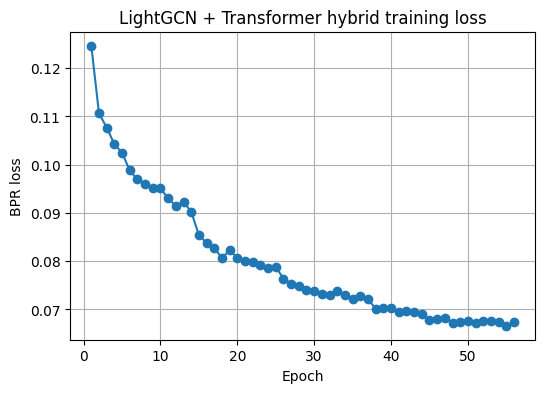

In [ ]:
# ============================================================
# Cell 29 (UPDATED) — Train hybrid model with early stopping + LR scheduling + L2
# ============================================================
hybrid_optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=HYBRID_LEARNING_RATE, weight_decay=L2_REG)
hybrid_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    hybrid_optimizer, mode="max", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE, min_lr=LR_MIN
)

hybrid_train_losses = []
hybrid_val_ndcg20_history = []
best_hybrid_val_ndcg20 = -1.0
best_hybrid_state = None
best_hybrid_epoch = -1
epochs_without_improvement = 0

hybrid_start_time = time.time()

for epoch in range(1, HYBRID_MAX_EPOCHS + 1):
    hybrid_model.train()
    epoch_loss = 0.0
    num_batches = 0

    loader = get_seq_bpr_dataloader(batch_size=HYBRID_BATCH_SIZE, shuffle=True)
    for user_batch, seq_batch, len_batch, target_batch, neg_batch in loader:
        user_batch = user_batch.to(DEVICE).long()
        seq_batch = seq_batch.to(DEVICE)
        len_batch = len_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)
        neg_batch = neg_batch.to(DEVICE)

        pos_scores, neg_scores = hybrid_model(user_batch, seq_batch, len_batch, target_batch, neg_batch)
        loss = bpr_loss(pos_scores, neg_scores)

        hybrid_optimizer.zero_grad()
        loss.backward()
        hybrid_optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    hybrid_train_losses.append(avg_loss)

    hybrid_score_fn = make_hybrid_score_fn(hybrid_model, user_train_items)
    val_metrics = evaluate_topk(hybrid_score_fn, user_val_item, user_train_items_set, NUM_ITEMS)
    hybrid_val_ndcg20_history.append(val_metrics["NDCG@20"])

    hybrid_scheduler.step(val_metrics["NDCG@20"])
    current_lr = hybrid_optimizer.param_groups[0]["lr"]

    print(f"[Hybrid] Epoch {epoch}/{HYBRID_MAX_EPOCHS} - loss: {avg_loss:.4f} - "
          f"val Recall@20: {val_metrics['Recall@20']:.4f} - val NDCG@20: {val_metrics['NDCG@20']:.4f} - "
          f"lr: {current_lr:.6f}")

    if val_metrics["NDCG@20"] > best_hybrid_val_ndcg20:
        best_hybrid_val_ndcg20 = val_metrics["NDCG@20"]
        best_hybrid_epoch = epoch
        best_hybrid_state = {k: v.clone() for k, v in hybrid_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"[Hybrid] Early stopping triggered at epoch {epoch} "
              f"(no improvement for {EARLY_STOP_PATIENCE} consecutive epochs).")
        break

hybrid_training_time_sec = time.time() - hybrid_start_time

if best_hybrid_state is not None:
    hybrid_model.load_state_dict(best_hybrid_state)

print(f"[Hybrid] Best validation NDCG@20: {best_hybrid_val_ndcg20:.4f} at epoch {best_hybrid_epoch}")
print(f"Hybrid training time: {hybrid_training_time_sec / 60:.2f} minutes")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(hybrid_train_losses) + 1), hybrid_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("LightGCN + Transformer hybrid training loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Cell 30 (UPDATED) — Evaluate hybrid model on test set
# ============================================================
hybrid_model.eval()
hybrid_test_score_fn = make_hybrid_score_fn(hybrid_model, user_train_items)
hybrid_test_metrics = evaluate_topk(
    hybrid_test_score_fn, user_test_item, user_train_and_val_items_set, NUM_ITEMS
)

results["LightGCN + Transformer"] = hybrid_test_metrics

print("LightGCN + Transformer (test):")
for k, v in hybrid_test_metrics.items():
    print(f"  {k} = {v:.4f}")

LightGCN + Transformer (test):
  Recall@10 = 0.1684
  NDCG@10 = 0.0849
  Recall@20 = 0.2607
  NDCG@20 = 0.1081


In [ ]:
# ============================================================
# Cell 31 — Final results summary (Stage 1–4)
# ============================================================
results_df = pd.DataFrame(results).T
results_df = results_df[["Recall@10", "Recall@20", "NDCG@10", "NDCG@20"]]
results_df = results_df.loc[
    [m for m in ["Popularity", "Matrix Factorization", "NGCF", "LightGCN",
                 "Transformer", "LightGCN + Transformer"] if m in results_df.index]
]

print(results_df)
print()
print(f"Best hybrid validation NDCG@20: {best_hybrid_val_ndcg20:.4f}")
print(f"Hybrid training time: {hybrid_training_time_sec / 60:.2f} minutes")

                        Recall@10  Recall@20   NDCG@10   NDCG@20
Popularity               0.041432   0.072920  0.019364  0.027217
Matrix Factorization     0.061319   0.104243  0.030762  0.041525
NGCF                     0.067948   0.111535  0.032399  0.043365
LightGCN                 0.068611   0.119490  0.034369  0.047080
Transformer              0.182135   0.279748  0.096393  0.120904
LightGCN + Transformer   0.168379   0.260689  0.084923  0.108112

Best hybrid validation NDCG@20: 0.1404
Hybrid training time: 71.53 minutes
